# MIO vs First-Order vs Lasso — experiments on synthetic data

This notebook compares three variable-selection methods for sparse regression:

- **MIO** — implemented in MIP.py,
- **First-Order** — implemented in MIP.py,
- **Lasso** — `LassoCV` from scikit-learn.

Experiments are repeated for **two synthetic data generators**:

1. `generate_data` 
2. `generate_data_v2` — the generator provided by paper on page 26 example 1, but with modified `beta0`, where the support is random and the nonzero coefficients have random sign and magnitude drawn from `Uniform(1, 10)`.

For each generator we run **3 experiments** (varying `SNR`, `n`, and `p` one at a time, keeping the rest fixed), each with **2 plots** (prediction error and sparsity — number of nonzero coefficients) 


## 0. Setup

In [32]:
# !pip install numpy scikit-learn gurobipy matplotlib kagglehub ucimlrepo

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
import time
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import KFold
from MIP import best_subset_full, discrete_first_order, best_subset_mio
from sklearn.metrics import mean_squared_error,confusion_matrix
import kagglehub
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import PolynomialFeatures
from ucimlrepo import fetch_ucirepo
plt.rcParams["figure.dpi"] = 110

## 1. Data generators

### 1.1 Generator 1 


In [34]:
def generate_data(n, p, k0, rho=0.5, SNR=3.0, seed=0):

    rng = np.random.default_rng(seed)

    idx = np.arange(p)
    Sigma = rho ** np.abs(idx[:, None] - idx[None, :])
    L = np.linalg.cholesky(Sigma)
    X = rng.standard_normal((n, p)) @ L.T

    X = X - X.mean(axis=0)
    X = X / np.linalg.norm(X, axis=0)

    beta0 = np.zeros(p)
    indices = np.round(np.linspace(0, p - 1, k0)).astype(int)
    beta0[indices] = 1.0

    signal_var = np.var(X @ beta0)
    sigma2 = signal_var / SNR
    eps = rng.normal(0, np.sqrt(sigma2), n)
    y = X @ beta0 + eps
    return X, y, beta0

### 1.2 Generator 2 (paper p.26 with modified b0)

In [35]:

def generate_data_v2(n, p=20, k0=10, rho=0.5, SNR=3.0, seed=10):

    np.random.seed(seed)

    Sigma = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            Sigma[i, j] = rho ** abs(i - j)

    X = np.random.multivariate_normal(np.zeros(p), Sigma, n)

    X = X - np.mean(X, axis=0)
    norm = np.linalg.norm(X, axis=0)
    norm[norm == 0] = 1
    X = X / norm

    beta0 = np.zeros(p)
    non_zero = np.random.choice(p, k0, replace=False)
    beta0[non_zero] = np.random.uniform(1, 10, k0) * np.random.choice([-1, 1], k0)

    y0 = X @ beta0

    var_f = np.var(y0)
    var_noise = var_f / SNR

    y = y0 + np.random.normal(0, np.sqrt(var_noise), n)
    #y=y0

    return X, y, beta0


# def generate_data_v2(n, p, k0, rho=0.5, SNR=3.0, seed=10):
#     #rename arg
#     return generate_data_example1(n, p=p, k_true=k0, rho=rho, snr=SNR, seed=seed)

## 2. Helper functions 

In [36]:
def prediction_error(X, beta_hat, beta0):

    num = np.sum((X @ beta_hat - X @ beta0) ** 2)
    den = np.sum((X @ beta0) ** 2)
    if den < 1e-10:
        return 0.0
    return num / den


def select_k_by_validation(X_train, y_train, X_val, y_val,
                            k_range, method="mio", time_limit=60):

    best_k = k_range[0]
    best_val_loss = np.inf
    for k in k_range:
        if method == "mio":
            result = best_subset_full(X_train, y_train, k,
                                      time_limit=time_limit, n_restarts=20)
            beta = result["beta_mio"]
            if beta is None:
                beta = result["beta_fo"]
        else:  # first_order
            beta, _ = discrete_first_order(X_train, y_train, k, n_restarts=20)

        val_loss = np.mean((y_val - X_val @ beta) ** 2)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_k = k
    return best_k

## 3. Experiment runner

`run_experiment` - 60/20/20 train/val/test split, validation-based selection of `k`, fitting MIO/FO/Lasso, computing prediction error and sparsity,over a grid of values for a single varying parameter (`n`, `p`, or `snr`), keeping the remaining parameters fixed.

In [37]:
def run_experiment(data_gen, varying_param, values, n_fixed, p_fixed, snr_fixed,
                    k0=10, rho=0.5, n_repeats=1, time_limit_mio=30, time_limit_full=60):

    results = {v: {"mio": [], "lasso": [], "fo": []} for v in values}

    for v in values:
        n = v if varying_param == "n" else n_fixed
        p = v if varying_param == "p" else p_fixed
        snr = v if varying_param == "snr" else snr_fixed

        print(f"DONE {varying_param} = {v} ")

        for rep in range(n_repeats):
            X, y, beta0 = data_gen(n, p, k0, rho=rho, SNR=snr, seed=rep)

            n_train = int(0.6 * n)
            n_val = int(0.2 * n)
            X_train, y_train = X[:n_train], y[:n_train]
            X_val, y_val = X[n_train:n_train + n_val], y[n_train:n_train + n_val]
            X_test, y_test = X[n_train + n_val:], y[n_train + n_val:]

            k_range = list(range(max(1, k0 - 5), k0 + 6))

            t0 = time.time()
            best_k_mio = select_k_by_validation(
                X_train, y_train, X_val, y_val,
                k_range, method="mio", time_limit=time_limit_mio
            )
            result = best_subset_full(X_train, y_train, best_k_mio,
                                      time_limit=time_limit_full, n_restarts=30)
            beta_mio = result["beta_mio"] if result["beta_mio"] is not None else result["beta_fo"]
            pe_mio = prediction_error(X_test, beta_mio, beta0)
            nnz_mio = int(np.sum(np.abs(beta_mio) > 1e-6))
            gap_mio = result["mio_gap"]
            t_mio = time.time() - t0

            t0 = time.time()
            best_k_fo = select_k_by_validation(
                X_train, y_train, X_val, y_val,
                k_range, method="first_order", time_limit=time_limit_mio
            )
            beta_fo, _ = discrete_first_order(X_train, y_train, best_k_fo, n_restarts=50)
            pe_fo = prediction_error(X_test, beta_fo, beta0)
            nnz_fo = int(np.sum(np.abs(beta_fo) > 1e-6))
            t_fo = time.time() - t0

            t0 = time.time()
            lasso_cv = LassoCV(cv=5, max_iter=5000).fit(X_train, y_train)
            beta_lasso = lasso_cv.coef_
            pe_lasso = prediction_error(X_test, beta_lasso, beta0)
            nnz_lasso = int(np.sum(np.abs(beta_lasso) > 1e-6))
            t_lasso = time.time() - t0

            results[v]["mio"].append({
                "pred_err": pe_mio, "nnz": nnz_mio, "gap": gap_mio, "time": t_mio, "k": best_k_mio
            })
            results[v]["lasso"].append({
                "pred_err": pe_lasso, "nnz": nnz_lasso, "time": t_lasso
            })
            results[v]["fo"].append({
                "pred_err": pe_fo, "nnz": nnz_fo, "time": t_fo, "k": best_k_fo
            })



    return results

## 4. Plotting function (prediction error + sparsity)

In [38]:
def plot_error_and_sparsity(results, values, varying_param, k0, title_suffix=""):

    methods = [("mio", "MIO", "steelblue", "o"),
               ("fo", "First-Order", "darkorange", "s"),
               ("lasso", "Lasso", "crimson", "^")]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    xlabel = {"n": "n (number of observations)", "p": "p (number of variables)", "snr": "SNR"}[varying_param]


    ax = axes[0]
    for key, label, color, marker in methods:
        means = [np.mean([d["pred_err"] for d in results[v][key]]) for v in values]
        ax.plot(values, means, marker=marker, color=color, label=label, linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Prediction error")
    ax.set_title(f"Prediction error vs {varying_param}{title_suffix}")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    for key, label, color, marker in methods:
        means = [np.mean([d["nnz"] for d in results[v][key]]) for v in values]
        ax.plot(values, means, marker=marker, color=color, label=label, linewidth=2)
    ax.axhline(k0, color="black", linestyle="--", linewidth=1.5, label=f"True k₀={k0}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Avg # nonzeros")
    ax.set_title(f"Sparsity vs {varying_param}{title_suffix}")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    return fig

## 5. Shared experiment settings

For each of the two generators we run three experiments:

- varying **SNR**  with n=800, p=30 fixed,
- varying **n**  with p=30, SNR=3 fixed,
- varying **p**  with n=800, SNR=3 fixed.

`n_repeats=3` 

In [39]:
K0 = 10
RHO = 0.5
N_REPEATS = 3

SNR_VALUES = [0.5,1,1.5,2,2.5, 3,3.5,4.5, 5,5.5,6]
N_VALUES = [200,300, 400,500, 600,700,800,900,1000,1200,1350,1500,1600,1750,1800,2000,2200,2500]
P_VALUES = [10,20,30,40,50,60,70,80,90, 100]

N_FIXED = 800
P_FIXED = 30
SNR_FIXED = 3.0

## 6. Generator 1 

### 6.1 Varying SNR

In [40]:
results_g1_snr = run_experiment(
    generate_data, "snr", SNR_VALUES,
    n_fixed=N_FIXED, p_fixed=P_FIXED, snr_fixed=SNR_FIXED,
    k0=K0, rho=RHO, n_repeats=N_REPEATS
)

DONE snr = 0.5 
DONE snr = 1 
DONE snr = 1.5 
DONE snr = 2 
DONE snr = 2.5 
DONE snr = 3 
DONE snr = 3.5 
DONE snr = 4.5 
DONE snr = 5 
DONE snr = 5.5 
DONE snr = 6 


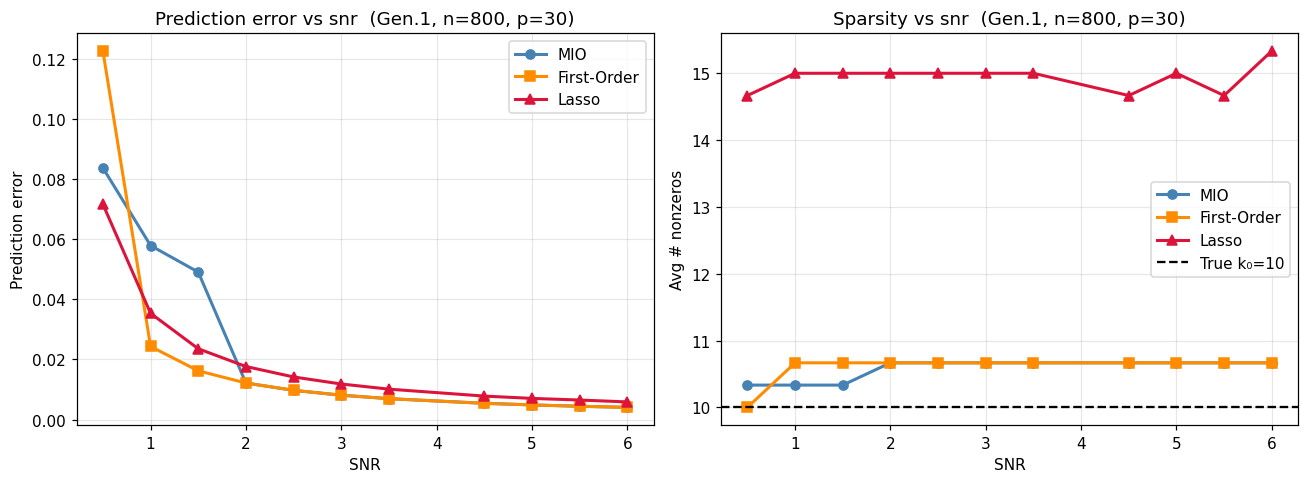

In [41]:
fig = plot_error_and_sparsity(results_g1_snr, SNR_VALUES, "snr", K0,
                               title_suffix=f"  (Gen.1, n={N_FIXED}, p={P_FIXED})")
plt.savefig("plots/gen1_snr.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 Varying n

In [42]:
results_g1_n = run_experiment(
    generate_data, "n", N_VALUES,
    n_fixed=N_FIXED, p_fixed=P_FIXED, snr_fixed=SNR_FIXED,
    k0=K0, rho=RHO, n_repeats=N_REPEATS
)

DONE n = 200 
DONE n = 300 
DONE n = 400 
DONE n = 500 
DONE n = 600 
DONE n = 700 
DONE n = 800 
DONE n = 900 
DONE n = 1000 
DONE n = 1200 
DONE n = 1350 
DONE n = 1500 
DONE n = 1600 
DONE n = 1750 
DONE n = 1800 
DONE n = 2000 
DONE n = 2200 
DONE n = 2500 


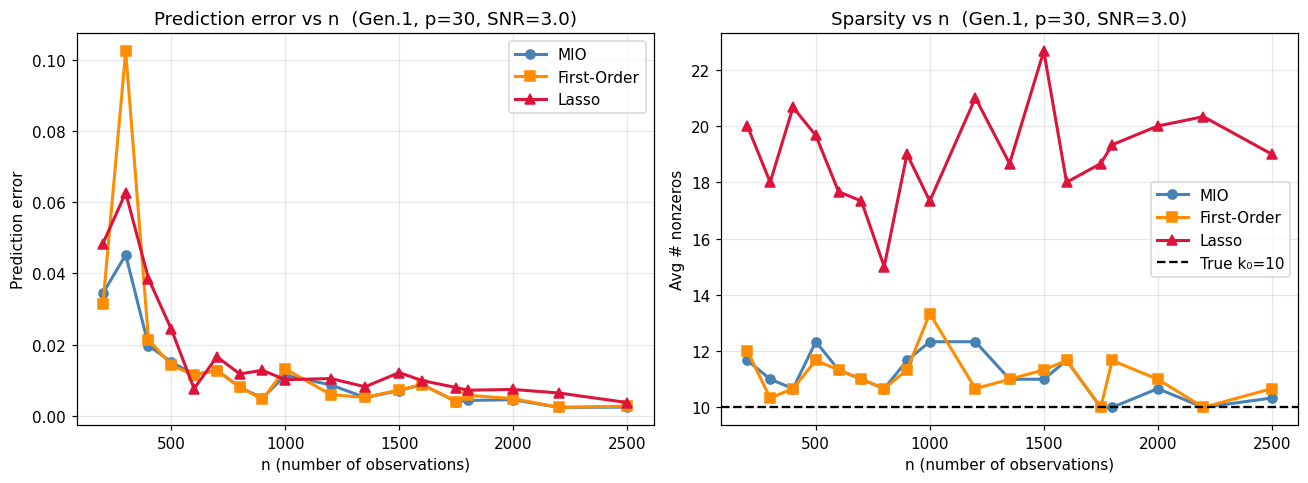

In [43]:
fig = plot_error_and_sparsity(results_g1_n, N_VALUES, "n", K0,
                               title_suffix=f"  (Gen.1, p={P_FIXED}, SNR={SNR_FIXED})")
plt.savefig("plots/gen1_n.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3 Varying p

In [44]:
results_g1_p = run_experiment(
    generate_data, "p", P_VALUES,
    n_fixed=N_FIXED, p_fixed=P_FIXED, snr_fixed=SNR_FIXED,
    k0=K0, rho=RHO, n_repeats=N_REPEATS
)

DONE p = 10 
DONE p = 20 
DONE p = 30 
DONE p = 40 
DONE p = 50 
DONE p = 60 
DONE p = 70 
DONE p = 80 
DONE p = 90 
DONE p = 100 


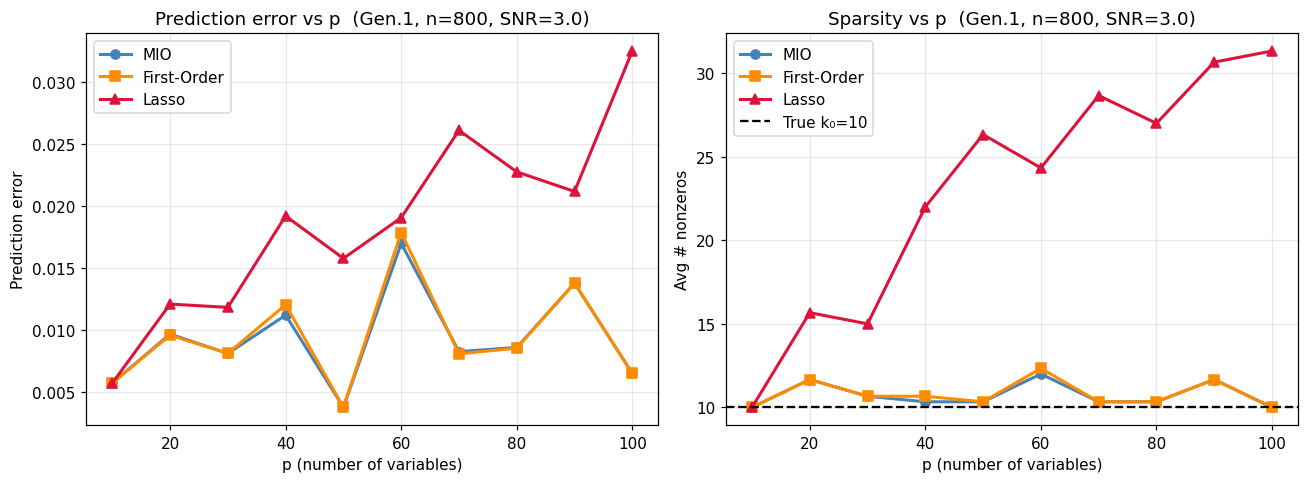

In [45]:
fig = plot_error_and_sparsity(results_g1_p, P_VALUES, "p", K0,
                               title_suffix=f"  (Gen.1, n={N_FIXED}, SNR={SNR_FIXED})")
plt.savefig("plots/gen1_p.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Generator 2 — `generate_data_v2` (user-provided generator, Example 1 p. 26)

### 7.1 Varying SNR

In [46]:
results_g2_snr = run_experiment(
    generate_data_v2, "snr", SNR_VALUES,
    n_fixed=N_FIXED, p_fixed=P_FIXED, snr_fixed=SNR_FIXED,
    k0=K0, rho=RHO, n_repeats=N_REPEATS
)

DONE snr = 0.5 
DONE snr = 1 
DONE snr = 1.5 
DONE snr = 2 
DONE snr = 2.5 
DONE snr = 3 
DONE snr = 3.5 
DONE snr = 4.5 
DONE snr = 5 
DONE snr = 5.5 
DONE snr = 6 


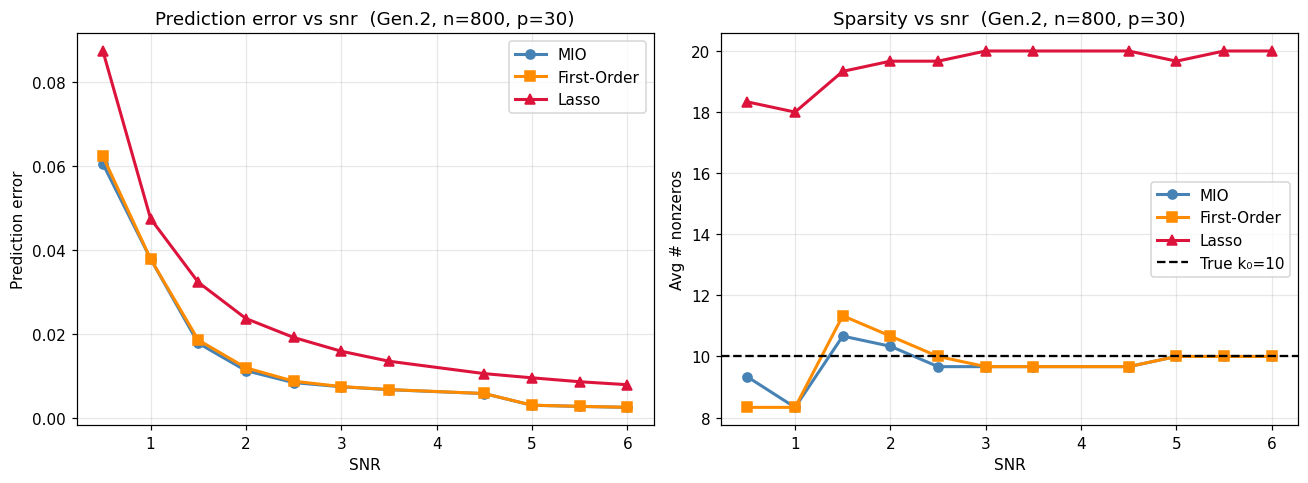

In [47]:
fig = plot_error_and_sparsity(results_g2_snr, SNR_VALUES, "snr", K0,
                               title_suffix=f"  (Gen.2, n={N_FIXED}, p={P_FIXED})")
plt.savefig("plots/gen2_snr.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.2 Varying n

In [48]:
results_g2_n = run_experiment(
    generate_data_v2, "n", N_VALUES,
    n_fixed=N_FIXED, p_fixed=P_FIXED, snr_fixed=SNR_FIXED,
    k0=K0, rho=RHO, n_repeats=N_REPEATS
)

DONE n = 200 
DONE n = 300 
DONE n = 400 
DONE n = 500 
DONE n = 600 
DONE n = 700 
DONE n = 800 
DONE n = 900 
DONE n = 1000 
DONE n = 1200 
DONE n = 1350 
DONE n = 1500 
DONE n = 1600 
DONE n = 1750 
DONE n = 1800 
DONE n = 2000 
DONE n = 2200 
DONE n = 2500 


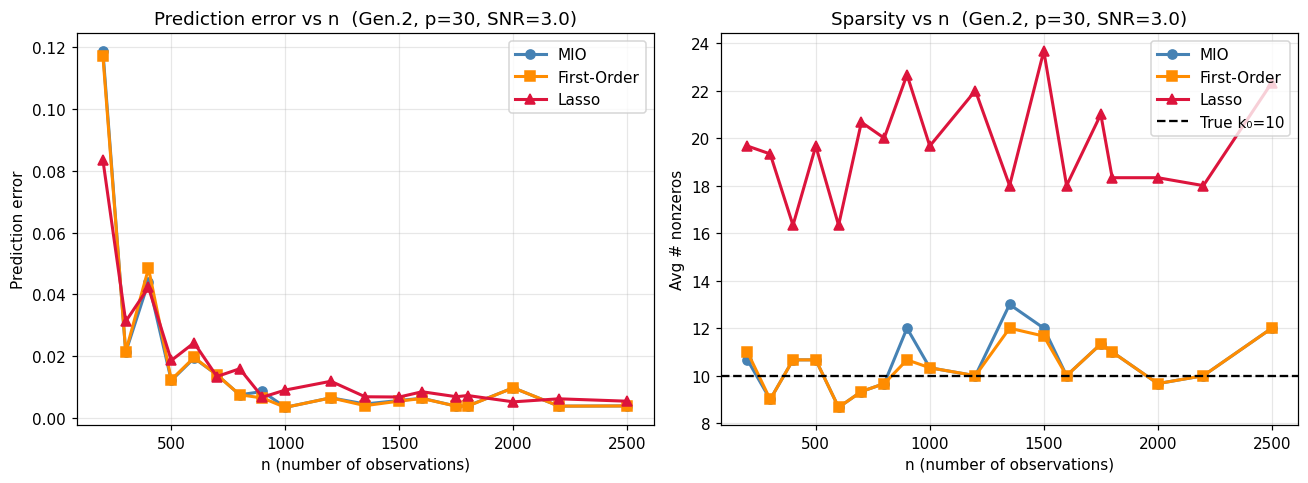

In [49]:
fig = plot_error_and_sparsity(results_g2_n, N_VALUES, "n", K0,
                               title_suffix=f"  (Gen.2, p={P_FIXED}, SNR={SNR_FIXED})")
plt.savefig("plots/gen2_n.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.3 Varying p

In [50]:
results_g2_p = run_experiment(
    generate_data_v2, "p", P_VALUES,
    n_fixed=N_FIXED, p_fixed=P_FIXED, snr_fixed=SNR_FIXED,
    k0=K0, rho=RHO, n_repeats=N_REPEATS
)

DONE p = 10 
DONE p = 20 
DONE p = 30 
DONE p = 40 
DONE p = 50 
DONE p = 60 
DONE p = 70 
DONE p = 80 
DONE p = 90 
DONE p = 100 


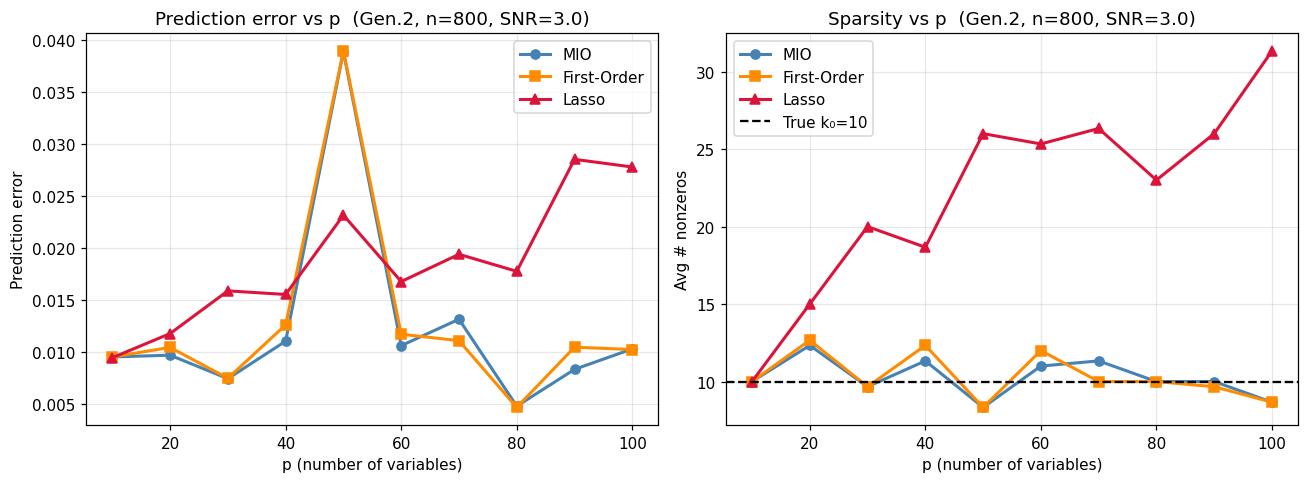

In [51]:
fig = plot_error_and_sparsity(results_g2_p, P_VALUES, "p", K0,
                               title_suffix=f"  (Gen.2, n={N_FIXED}, SNR={SNR_FIXED})")
plt.savefig("plots/gen2_p.png", dpi=150, bbox_inches="tight")
plt.show()

# Real dataset 

In [ ]:
# !pip install ucimlrepo

In [ ]:
def standardize_l2(X, y):
    X_std = X - X.mean(axis=0)

    l2_norms = np.linalg.norm(X_std, axis=0)
    l2_norms[l2_norms == 0] = 1

    X_std = X_std / l2_norms

    y_std = y - y.mean()
    y_std = y_std / np.linalg.norm(y_std)

    return X_std, y_std

In [ ]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)
X_quad = poly.fit_transform(X)

X, y = standardize_l2(X_quad, y)

In [ ]:
X.shape

(442, 65)

In [ ]:
K_RANGE = [5, 10, 15, 20, 25,30,35,40]
N_FOLDS = 5
TIME_LIMIT_MIO = 30
TIME_LIMIT_FULL = 60

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=0)

cv_results = {"mio": [], "fo": [], "lasso": []}

fold = 0
for train_idx, test_idx in kf.split(X):
    fold += 1
    print(f"Fold {fold}/{N_FOLDS}")

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

  
    n_tr = X_train.shape[0]
    n_inner_train = int(0.75 * n_tr)
    rng = np.random.default_rng(fold)
    perm = rng.permutation(n_tr)
    itr_idx, ival_idx = perm[:n_inner_train], perm[n_inner_train:]
    X_itr, y_itr = X_train[itr_idx], y_train[itr_idx]
    X_ival, y_ival = X_train[ival_idx], y_train[ival_idx]


    t0 = time.time()
    best_k_mio = select_k_by_validation(X_itr, y_itr, X_ival, y_ival, K_RANGE,
                                         method="mio", time_limit=TIME_LIMIT_MIO)
    result = best_subset_full(X_train, y_train, best_k_mio,
                               time_limit=TIME_LIMIT_FULL, n_restarts=30)
    beta_mio = result["beta_mio"] if result["beta_mio"] is not None else result["beta_fo"]
    mse_mio = mean_squared_error(y_test, X_test @ beta_mio)
    nnz_mio = int(np.sum(np.abs(beta_mio) > 1e-6))
    t_mio = time.time() - t0


    t0 = time.time()
    best_k_fo = select_k_by_validation(X_itr, y_itr, X_ival, y_ival, K_RANGE,
                                        method="first_order", time_limit=TIME_LIMIT_MIO)
    beta_fo, _ = discrete_first_order(X_train, y_train, best_k_fo, n_restarts=50)
    mse_fo = mean_squared_error(y_test, X_test @ beta_fo)
    nnz_fo = int(np.sum(np.abs(beta_fo) > 1e-6))
    t_fo = time.time() - t0


    t0 = time.time()
    lasso_cv = LassoCV(cv=5, max_iter=5000).fit(X_train, y_train)
    beta_lasso = lasso_cv.coef_
    mse_lasso = mean_squared_error(y_test, X_test @ beta_lasso)
    nnz_lasso = int(np.sum(np.abs(beta_lasso) > 1e-6))
    t_lasso = time.time() - t0

    cv_results["mio"].append({"mse": mse_mio, "nnz": nnz_mio, "time": t_mio, "k": best_k_mio})
    cv_results["fo"].append({"mse": mse_fo, "nnz": nnz_fo, "time": t_fo, "k": best_k_fo})
    cv_results["lasso"].append({"mse": mse_lasso, "nnz": nnz_lasso, "time": t_lasso})


Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5


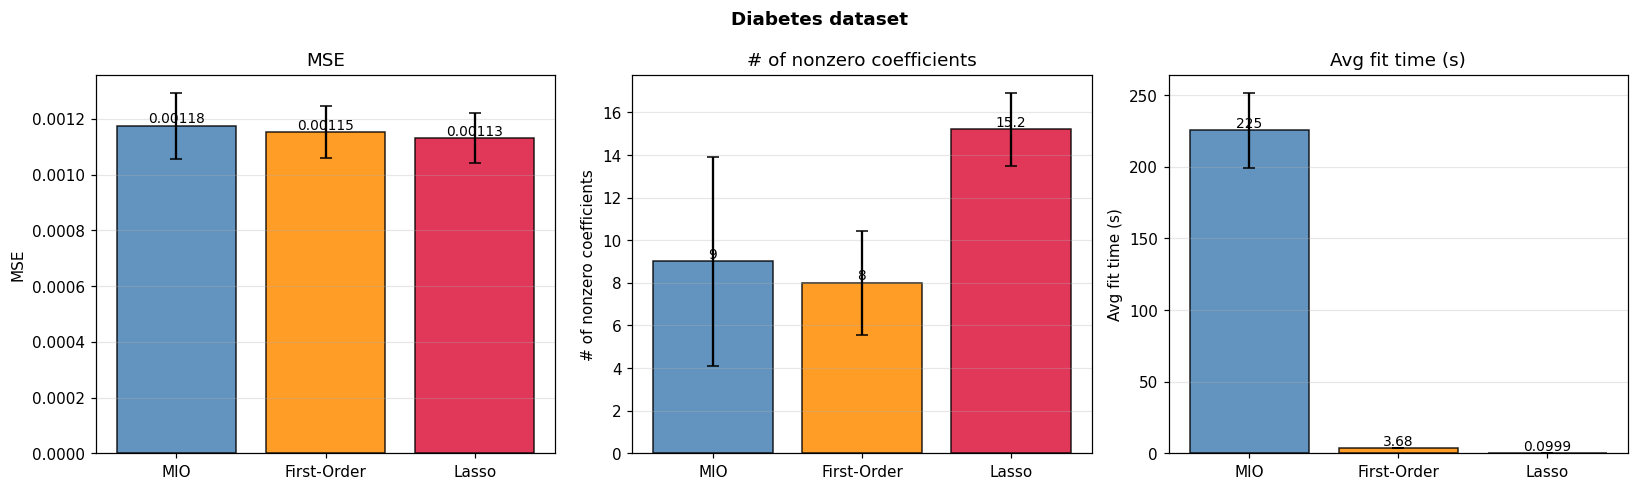

In [ ]:
methods = [("mio", "MIO", "steelblue"), ("fo", "First-Order", "darkorange"), ("lasso", "Lasso", "crimson")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric, ylabel in zip(
    axes,
    ["mse", "nnz", "time"],
    ["MSE", "# of nonzero coefficients", "Avg fit time (s)"]
):
    means = [np.mean([d[metric] for d in cv_results[key]]) for key, _, _ in methods]
    stds = [np.std([d[metric] for d in cv_results[key]]) for key, _, _ in methods]
    labels = [label for _, label, _ in methods]
    colors = [color for _, _, color in methods]
    bars = ax.bar(labels, means, yerr=stds, color=colors, alpha=0.85, edgecolor="black", capsize=4)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(alpha=0.3, axis="y")
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.3g}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Diabetes dataset", fontweight="bold")
plt.tight_layout()
plt.savefig("plots/diabetes_comparison.png", dpi=150, bbox_inches="tight")
plt.show()